House Price Prediction Project


Multiple Linear Regression


In [26]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [28]:
df = pd.read_csv("train.csv")

In [29]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePri

Select Required Columns

In [30]:
df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

In [31]:
print("\nSelected Features:")
print(df.head())


Selected Features:
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       1710             3         2     208500
1       1262             3         2     181500
2       1786             3         2     223500
3       1717             3         1     140000
4       2198             4         2     250000


Check Missing Values

In [32]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


Drop missing values

In [33]:
df = df.dropna()

Exploratory Data Analysis

Correlation heatmap

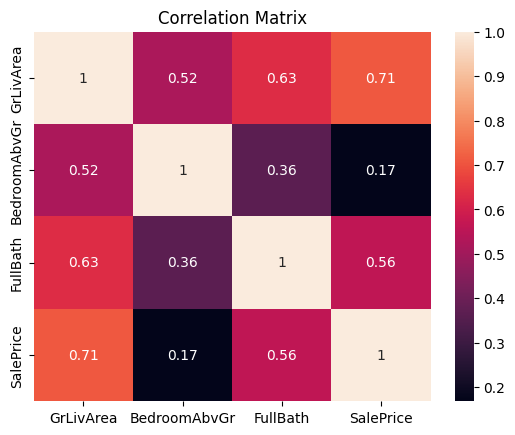

In [34]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Scatter plot

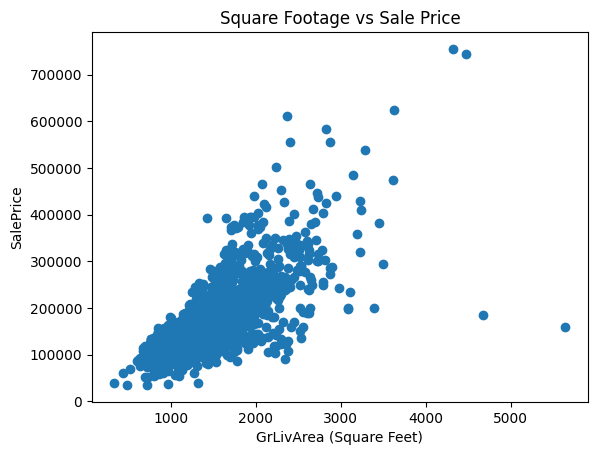

In [35]:
plt.figure()
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea (Square Feet)")
plt.ylabel("SalePrice")
plt.title("Square Footage vs Sale Price")
plt.show()

Define Features (X) and Target (y)

In [36]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = df['SalePrice']

Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Create and Train Model

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model Parameters

In [39]:
print("\nModel Intercept:", model.intercept_)
print("Model Coefficients:", model.coef_)


Model Intercept: 52261.74862694461
Model Coefficients: [   104.02630701 -26655.16535734  30014.32410896]


Equation Display

In [40]:
print("\nLinear Regression Equation:")
print(f"SalePrice = {model.intercept_:.2f} "
      f"+ ({model.coef_[0]:.2f} * GrLivArea) "
      f"+ ({model.coef_[1]:.2f} * Bedrooms) "
      f"+ ({model.coef_[2]:.2f} * FullBath)")


Linear Regression Equation:
SalePrice = 52261.75 + (104.03 * GrLivArea) + (-26655.17 * Bedrooms) + (30014.32 * FullBath)


Make Predictions

In [41]:
y_pred = model.predict(X_test)

Model Evaluation

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [43]:
print("\nModel Evaluation:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation:
MAE : 35788.061292436294
MSE : 2806426667.247853
RMSE: 52975.71771338122
R2 Score: 0.6341189942328371


Actual vs Predicted Plot

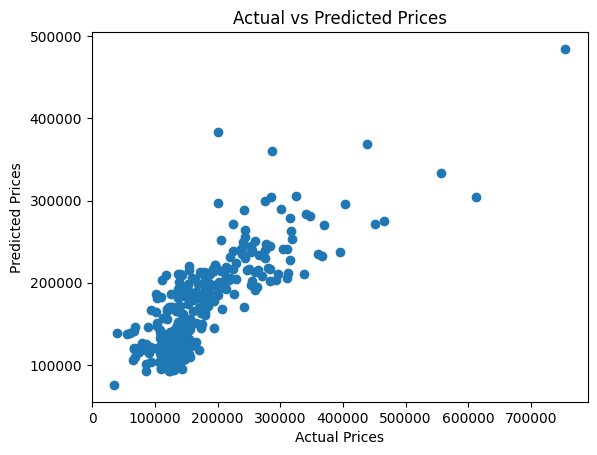

In [44]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

Example Prediction

In [45]:
example_house = [[2000, 3, 2]]  # 2000 sq ft, 3 bedrooms, 2 bathrooms
predicted_price = model.predict(example_house)
print("\nPredicted Price for 2000 sq ft, 3 bed, 2 bath house:",
      predicted_price[0])



Predicted Price for 2000 sq ft, 3 bed, 2 bath house: 240377.51479736282


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
